## Algoritmos de Clasificación


algoritmos:
KNN: Se basa en la proximidad de los datos

Normalizacion min-max: Xnorm=(X-Xmin)/(Xmax-Xmin):rango entre 0-1

Estandarizacion z-score: Xstd=(X-media)/(desviacion estandar)=(X-u)/d : situa la media en el 0 

Exactitud: Predicciones correctas/Total de predicciones: [+]: casilla 1 / (casilla 1 + casilla 4)
[12]
[34]

In [12]:
import pandas as pd 
import numpy as np 

df=pd.read_csv('data_procesada.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               8 non-null      int64  
 1   index                    8 non-null      int64  
 2   id_clientes              8 non-null      int64  
 3   Edad                     8 non-null      float64
 4   Salario_Estimado         8 non-null      float64
 5   Saldo_Bancario           8 non-null      float64
 6   Genero                   8 non-null      float64
 7   Nivel_Educativo          8 non-null      float64
 8   Acepta_Tarjeta           8 non-null      int64  
 9   Estado_Civil_Divorciado  8 non-null      bool   
dtypes: bool(1), float64(5), int64(4)
memory usage: 712.0 bytes


In [13]:
X=df.drop('Acepta_Tarjeta',axis=1,index=None)
X = X.drop(columns=['Unnamed: 0','index','id_clientes'])
X


,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Estado_Civil_Divorciado
0,-0.625094,0.919145,1.329665,1.0,0.160128,False
1,0.814517,-0.656532,0.433394,0.0,0.160128,True
2,-1.610091,-0.656532,-0.187586,1.0,-1.120897,False
3,-0.549325,0.131306,0.617083,1.0,1.441153,False
4,1.117593,-0.656532,-1.511217,1.0,-1.120897,False
5,-1.003939,-0.656532,-0.513053,1.0,-1.120897,False
6,0.738748,2.232209,-1.322493,1.0,1.441153,False
7,1.117593,-0.656532,1.154206,0.0,0.160128,False


In [14]:
y=df['Acepta_Tarjeta']
y

0    0
1    1
2    1
3    0
4    1
5    0
6    1
7    1
Name: Acepta_Tarjeta, dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X)

,copy,True
,with_mean,True
,with_std,True


In [16]:
X.shape

(8, 6)

In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [18]:
#modelamiento
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
X_test

,Edad,Salario_Estimado,Saldo_Bancario,Genero,Nivel_Educativo,Estado_Civil_Divorciado
1,0.814517,-0.656532,0.433394,0.0,0.160128,True
5,-1.003939,-0.656532,-0.513053,1.0,-1.120897,False


In [20]:
knn.predict(X_test)

array([1, 1])

In [21]:
comparacion=pd.DataFrame(y_test)
comparacion['Prediccion']=knn.predict(X_test)
comparacion

,Acepta_Tarjeta,Prediccion
1,1,1
5,0,1


METODO CLASE
        predicho
        lllllllllllllll
        lTrue  l Falsel
        lPositil Positl
        lllllllllllllll
real    lFalse l True l
        lNegatilNegatil
        lllllllllllllll


Precision=            TP/(TP+FP): primer_cuadrante/(horizontal)

Exactitud=            TP+TN/(TP+TN+FP+FN): Diagonal/todos_los_cuadrantes

Sensibilidad o Recall=TP/(TP+FN): primer_cuadrante/(Vertical_1)

Especifidad=          TN/(TN+FP) : tercer_cuadrante/(vertical_2)




METODO CONVENCIONAL CHATGPT

        predicho
        lllllllllllllll
        lTrue  l Falsel
        lNegatil Positl
        lllllllllllllll
real    lFalse l True l
        lNegatilPositil
        lllllllllllllll

Precision=            TP/(TP+FP): 4to_cuadrante/(Vertical_2)

Exactitud o accuracy= TP+TN/(TP+TN+FP+FN): Diagonal/todos_los_cuadrantes

Sensibilidad o Recall=TP/(TP+FN): 4to_cuadrante/(Horizontal_2)

Especifidad=          TN/(TN+FP) : 1er_cuadrante/(Horizontal_1)



F1=(2⋅Precision*Recall)/(Precision+Recall)​

In [22]:
#matriz de confusion
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,knn.predict(X_test))

array([[0, 1],
       [0, 1]])

In [23]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,knn.predict(X_test))

0.5

In [24]:
# clasification report
from sklearn.metrics import classification_report
print(classification_report(y_test,knn.predict(X_test)))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.50      1.00      0.67         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



c:\Curso Ciencia de Datos Talento Digital\clases grabadas\Clase 31\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Curso Ciencia de Datos Talento Digital\clases grabadas\Clase 31\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Curso Ciencia de Datos Talento Digital\clases grabadas\Clase 31\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [25]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test,knn.predict(X_test))

0.5

In [26]:
import matplotlib.pyplot as plt 

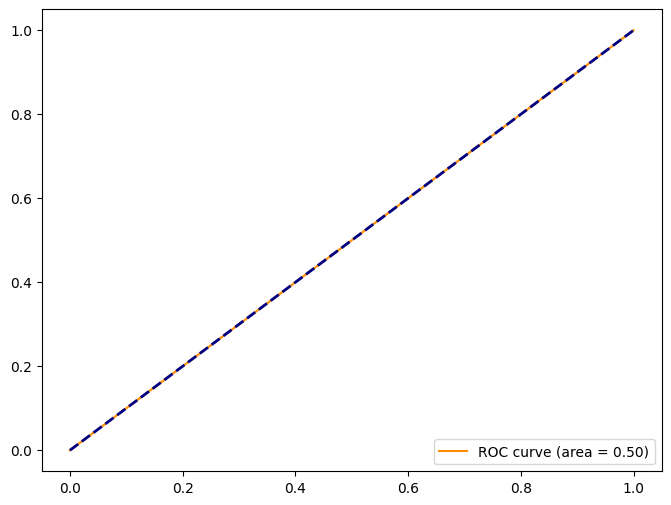

In [27]:
from sklearn.metrics import roc_curve,auc
import matplotlib.pyplot as plt
fpr,tpr,thresholds=roc_curve(y_test,knn.predict(X_test))
roc_auc=auc(fpr,tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc )
plt.plot([0,1],[0,1], color='navy',lw=2,linestyle='--')
plt.legend(loc='lower right')


In [28]:
#modelamiento arbol
from sklearn.tree import DecisionTreeClassifier

dtc=DecisionTreeClassifier()
dtc.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
comparacion=pd.DataFrame(y_test)
comparacion['Prediccion']=dtc.predict(X_test)
comparacion

,Acepta_Tarjeta,Prediccion
1,1,1
5,0,1
